In [283]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None) 

The train set will be used to inspect the data - find correlations, outliers and missing values. 

In [284]:
df = pd.read_csv("datasets/KOI_train_set.csv")

In [285]:
df.head()

,group_id,label,orbital_period_days,eccentricity,impact_parameter,transit_duration_hours,transit_depth,radius_ratio_rp_rs,inclination_deg,a_over_rs,planet_radius_rearth,semi_major_axis_au,equilibrium_temp_k,insolation_earth,stellar_teff_k,stellar_logg_cgs,stellar_metallicity_dex,stellar_radius_rsun,stellar_mass_msun
0,10797460,1,9.488036,0.0,0.146,2.95750,615.8,0.022344,89.66,24.810,2.26,0.0853,793.0,93.59,5455.0,4.467,0.14,0.927,0.919
1,10797460,1,54.418383,0.0,0.586,4.50700,874.8,0.027954,89.57,77.900,2.83,0.2734,443.0,9.11,5455.0,4.467,0.14,0.927,0.919
2,10848459,0,1.736952,0.0,1.276,2.40641,8079.2,0.387394,67.09,3.278,33.46,0.0267,1395.0,891.96,5805.0,4.564,-0.52,0.791,0.836
3,10854555,1,2.525592,0.0,0.701,1.65450,603.3,0.024064,85.41,8.750,2.75,0.0374,1406.0,926.16,6031.0,4.438,0.07,1.046,1.095
4,10872983,1,11.094321,0.0,0.538,4.59450,1517.5,0.036779,88.11,16.360,3.90,0.0992,835.0,114.81,6046.0,4.486,-0.08,0.972,1.053


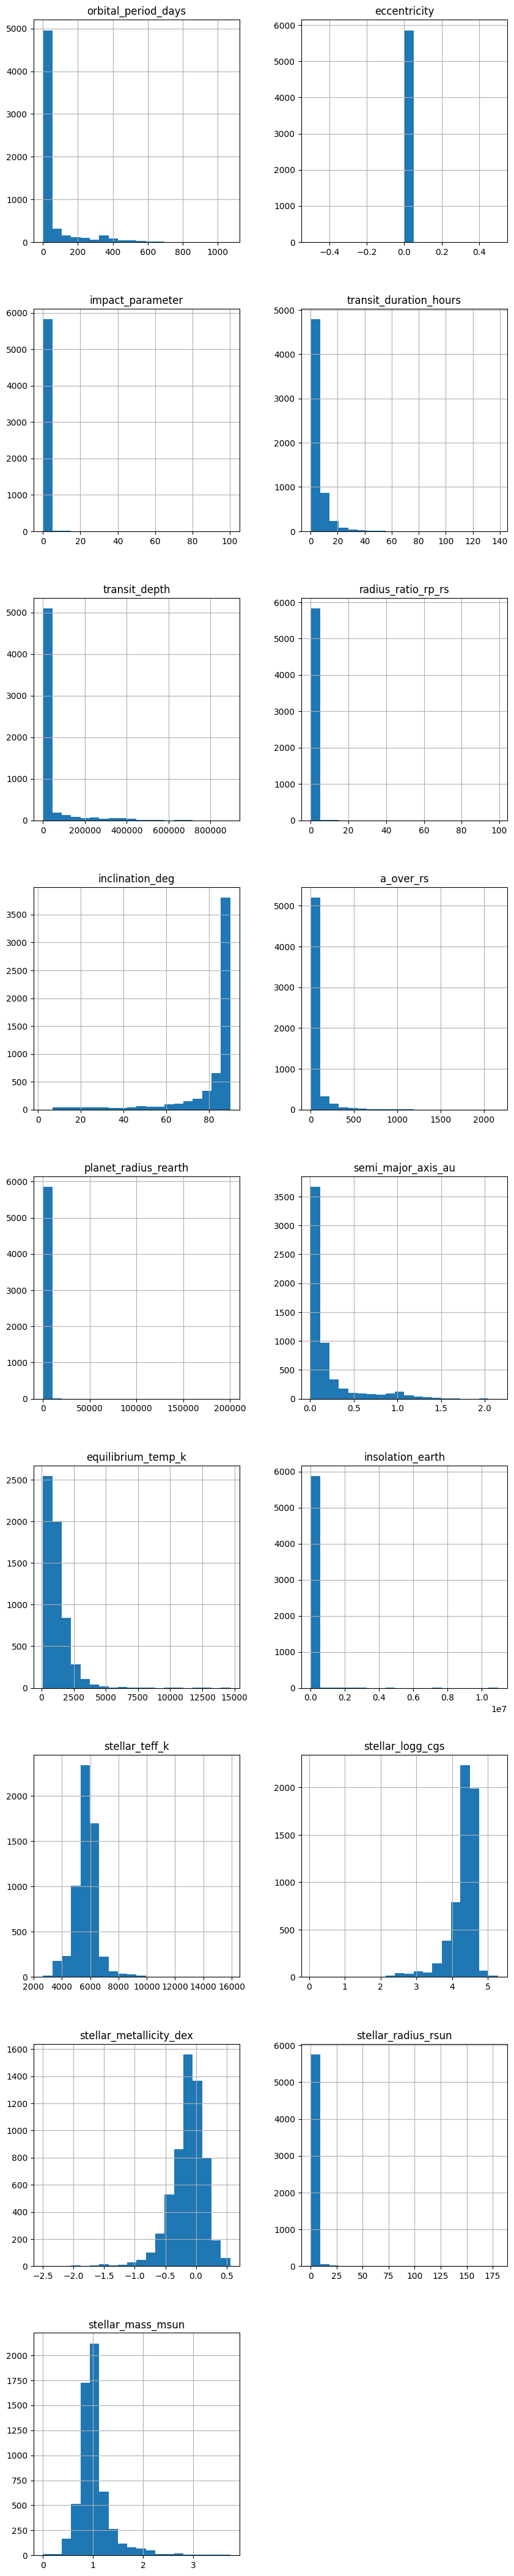

In [286]:
df_features = df.drop(["group_id", "label"], axis=1)
df_features.hist(bins=20, layout=(10, 2), figsize=(10, 60))
plt.show()

The majority of features seems rather skewed. We also see some features to have single values. These shall be removed.  
First, we will create a table with the following columns:   
"feature","n","missing_rate","n_unique","top_value_frac","p01","p25","median","p75","p99","IQR"  
This will allow us to inspect the distribution and the number of unique values per feature.

In [287]:
def feature_summary(df):
    s = []
    cols = df.columns
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce")
        x_non = x.dropna()
        if len(x_non) == 0:
            s.append([c, len(x), 1.0, 0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        vc = x_non.value_counts()
        top_frac = (vc.iloc[0] / len(x_non)) if len(vc) else np.nan

        q01, q05, q25, q50, q75, q95, q99 = np.percentile(x_non, [1,5,25,50,75,95,99])
        s.append([
            c,
            len(x),
            x.isna().mean(),
            x_non.nunique(),
            top_frac,
            q01, q25, q50, q75, q99,
            (q75 - q25),     
        ])
    return pd.DataFrame(s, columns=[
        "feature","n","missing_rate","n_unique","top_value_frac",
        "p01","p25","median","p75","p99","IQR"
    ]).sort_values(["missing_rate","top_value_frac"], ascending=[True, False])

In [288]:
summary = feature_summary(df_features)
display(summary)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
3,transit_duration_hours,6068,0.000000,5447,0.000659,0.840934,2.491750,3.856000,6.352500,33.814390,3.860750
0,orbital_period_days,6068,0.000000,6068,0.000165,0.523632,2.243522,8.101261,30.958968,512.455537,28.715446
11,insolation_earth,6068,0.029334,5305,0.001528,0.390000,26.990000,186.270000,1138.612500,86966.925700,1111.622500
1,eccentricity,6068,0.034773,1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,stellar_logg_cgs,6068,0.034773,1315,0.016391,2.459560,4.217000,4.438000,4.543000,4.801400,0.326000
16,stellar_mass_msun,6068,0.034773,1283,0.016220,0.470000,0.845000,0.972000,1.098000,2.575960,0.253000
15,stellar_radius_rsun,6068,0.034773,1869,0.015878,0.453120,0.831000,0.998000,1.355000,14.837120,0.524000
12,stellar_teff_k,6068,0.034773,2058,0.015025,3640.000000,5319.000000,5775.000000,6113.000000,8558.480000,794.000000
8,planet_radius_rearth,6068,0.034773,2404,0.004951,0.510000,1.520000,2.660000,24.770000,402.534000,23.250000
2,impact_parameter,6068,0.034773,1801,0.004268,0.003000,0.231000,0.586000,0.917000,1.969144,0.686000


No more than 3.5% of values in each column is missing, which is good. Furthermore, in all columns except for 'eccentricity' the number of unique values is high. 'eccentricity' will therefore be dropped.  
Several columns seem to be highly skewed, which has already been visible on histograms - logarithmic transformation will be applied on them.

In [289]:
right_skewed_cols = ["insolation_earth","transit_depth","a_over_rs", "planet_radius_rearth","orbital_period_days","semi_major_axis_au", "transit_duration_hours", "equilibrium_temp_k"]
left_skewed_cols = ["inclination_deg"]
drop_cols = ["eccentricity"]

In [290]:
df_features.drop(drop_cols, axis=1, inplace=True)
df_features_transformed = df_features.copy()
df_features_transformed[right_skewed_cols] = df_features_transformed[right_skewed_cols].apply(lambda s: np.log1p(s.clip(lower=0)))

In [291]:
eps = 1e-6

for col in left_skewed_cols:
    c = df_features_transformed[col].max(skipna=True) + eps
    reflected = (c - df_features_transformed[col])
    df_features_transformed[col] = np.log1p(reflected.clip(lower=0))

In [292]:
corr = df_features_transformed.corr(method="spearman")

In [293]:
def plot_corr_heatmap(corr, *, title="Correlation (Spearman/Pearson)", mask_upper=True, annotate=False, figsize=None):
    """
    corr: pandas DataFrame from df.corr(...)
    """
    corr_vals = corr.values.copy()

    # Mask upper triangle (optional)
    if mask_upper:
        mask = np.triu(np.ones_like(corr_vals, dtype=bool), k=1)
        corr_plot = np.ma.array(corr_vals, mask=mask)
    else:
        corr_plot = corr_vals

    n = corr.shape[0]
    if figsize is None:
        figsize = (max(6, 0.5 * n), max(5, 0.5 * n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr_plot, vmin=-1, vmax=1)   
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="corr")

    ax.set_title(title)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(n):
            for j in range(n):
                if mask_upper and j > i:
                    continue
                val = corr_vals[i, j]
                if np.isnan(val):
                    continue
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

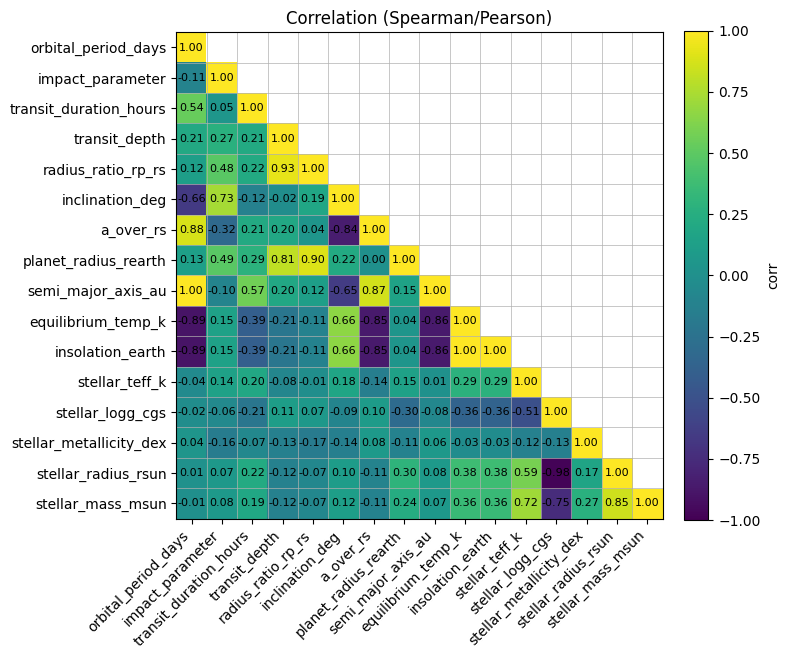

In [294]:
plot_corr_heatmap(corr, mask_upper=True, annotate=True)

We can notice 4 pairs of features with absolute correlation above 0.90 - `semi_major_axis_au` and `orbital_period_days`, `insolation_earth` and `equilibrium_temp_k`, `stellar_radius_rsun` and `stellar_log_cgs`, and `radius_ratio_rp_rs` and `transit_depth`. The third of these comes directly from the formula for stellar gravity, which is obtained by dividing radius by mass squared. For this reason, both stellar radius and mass features will be dropped.

In [295]:
drop_cols_2 = ['semi_major_axis_au', 'equilibrium_temp_k', 'radius_ratio_rp_rs', 'stellar_radius_rsun', 'stellar_mass_msun']

In [296]:
df_features_transformed2 = df_features_transformed.drop(drop_cols_2, axis=1)
corr2 = df_features_transformed2.corr(method="spearman")

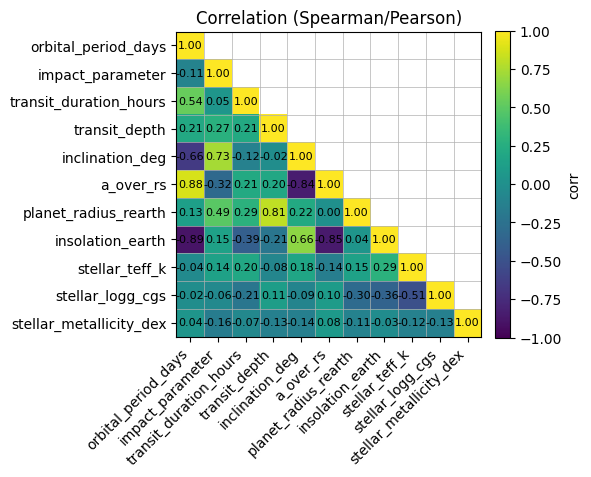

In [297]:
plot_corr_heatmap(corr2, annotate=True)

We can conduct a similar analysis for a KOI test set and a K2P set 

In [298]:
koi_test = pd.read_csv("datasets/KOI_test_set.csv")
k2p = pd.read_csv("datasets/K2P_set.csv")

In [299]:
drop = ["group_id", "label", "eccentricity", 'semi_major_axis_au', 'equilibrium_temp_k', 'radius_ratio_rp_rs', 'stellar_radius_rsun', 'stellar_mass_msun']
right_skewed = ["insolation_earth", "transit_depth", "a_over_rs", "planet_radius_rearth", "orbital_period_days", "transit_duration_hours"]
left_skewed = ["inclination_deg"]

In [300]:
koi_test.drop(drop, axis=1, inplace=True)
k2p.drop(drop, axis=1, inplace=True)
koi_test[right_skewed] = koi_test[right_skewed].apply(lambda s: np.log1p(s.clip(lower=0)))
k2p[right_skewed] = k2p[right_skewed].apply(lambda s: np.log1p(s.clip(lower=0)))

for col in left_skewed:
    c_koi = koi_test[col].max(skipna=True) + eps
    c_k2p = k2p[col].max(skipna=True) + eps
    reflected_koi = (c_koi - koi_test[col])
    reflected_k2p = (c_k2p - k2p[col])
    koi_test[col] = np.log1p(reflected_koi.clip(lower=0))
    k2p[col] = np.log1p(reflected_k2p.clip(lower=0))

In [301]:
summary_koi = feature_summary(koi_test)
summary_k2p = feature_summary(k2p)

In [302]:
display(summary_koi)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
2,transit_duration_hours,1517,0.000000,1483,0.001978,6.617382e-01,1.232269,1.553925,1.945910,3.319023,0.713641
0,orbital_period_days,1517,0.000000,1517,0.000659,4.195308e-01,1.168452,2.192575,3.386905,6.276416,2.218452
7,insolation_earth,1517,0.027027,1430,0.002710,3.293037e-01,3.374939,5.131997,7.114316,11.139851,3.739377
4,inclination_deg,1517,0.031641,777,0.077604,9.999995e-07,0.285180,1.111858,2.101692,4.361089,1.816513
9,stellar_logg_cgs,1517,0.031641,673,0.013615,2.593480e+00,4.224000,4.438000,4.544000,4.834040,0.320000
8,stellar_teff_k,1517,0.031641,912,0.010892,3.526000e+03,5300.000000,5774.000000,6120.000000,7988.240000,820.000000
1,impact_parameter,1517,0.031641,930,0.006807,4.408000e-03,0.213000,0.595000,0.918000,1.498680,0.705000
6,planet_radius_rearth,1517,0.031641,820,0.006807,4.446858e-01,0.900161,1.261298,3.091951,5.897082,2.191790
3,transit_depth,1517,0.031641,1403,0.002042,3.298646e+00,5.190175,6.153158,7.597547,13.092028,2.407372
5,a_over_rs,1517,0.031641,1343,0.002042,7.447904e-01,1.723124,2.649715,3.560762,6.834653,1.837638


In [303]:
display(summary_k2p)

,feature,n,missing_rate,n_unique,top_value_frac,p01,p25,median,p75,p99,IQR
0,orbital_period_days,830,0.007229,824,0.001214,0.408518,1.177278,1.949489,2.602922,5.472081,1.425643
8,stellar_teff_k,830,0.069880,582,0.009067,2899.840000,4439.250000,5291.500000,5754.000000,7801.694000,1314.750000
9,stellar_logg_cgs,830,0.184337,391,0.020679,3.498968,4.290000,4.490000,4.630000,5.128944,0.340000
6,planet_radius_rearth,830,0.257831,470,0.011364,0.562887,0.951561,1.193922,1.438056,4.182677,0.486494
10,stellar_metallicity_dex,830,0.313253,250,0.043860,-0.642547,-0.158875,-0.030000,0.080000,0.377240,0.238875
2,transit_duration_hours,830,0.453012,383,0.061674,0.477404,1.085460,1.333525,1.639151,2.666698,0.553692
5,a_over_rs,830,0.459036,423,0.006682,1.313784,2.493205,2.998229,3.367296,4.388886,0.874090
1,impact_parameter,830,0.549398,163,0.048128,0.059490,0.338500,0.410000,0.543000,0.956480,0.204500
3,transit_depth,830,0.597590,310,0.014970,5.038441,7.149460,9.837576,11.756380,13.398283,4.606920
4,inclination_deg,830,0.630120,243,0.022801,3.908657,3.951943,3.962868,3.986087,4.146568,0.034144


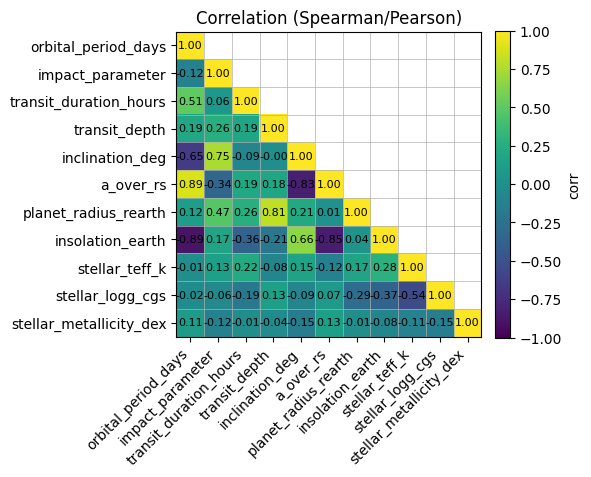

In [304]:
corr_koi = koi_test.corr(method="spearman")
plot_corr_heatmap(corr_koi, annotate=True)

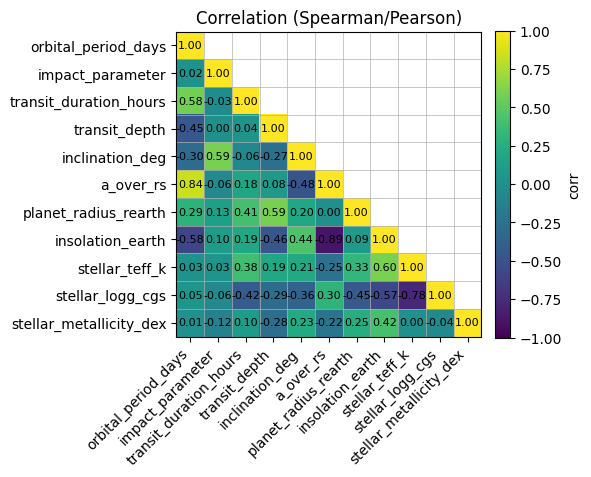

In [305]:
corr_k2p = k2p.corr(method="spearman")
plot_corr_heatmap(corr_k2p, annotate=True)

### Summary
In the next step, in the file `pipeline.ipynb`, a pipeline for data preprocessing will be created. It will:
* drop columns: ["eccentricity", 'semi_major_axis_au', 'equilibrium_temp_k', 'radius_ratio_rp_rs', 'stellar_radius_rsun', 'stellar_mass_msun']
* apply log transformation to features: ["insolation_earth", "transit_depth", "a_over_rs", "planet_radius_rearth", "orbital_period_days", "transit_duration_hours"] (right-skewed) and ["inclination_deg"] (left-skewed)
* perform further preprocessing for machine learning, described later in the file